In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import os 
import pandas as pd # 

In [2]:
df = pd.read_csv('match_data_50_tourns_modified.csv')

In [3]:
df.head()

,player1,player2,best_of,player1_elo,player2_elo,elo_match_win_rate,elo_frame_win_rate,p1_matches_played,p1_matches_won,p1_frames_played,...,p1_frames_won_3_years,p2_frames_played_1_year,p2_frames_won_1_year,p2_frames_played_3_years,p2_frames_won_3_years,score1,score2,match_result,win_percentage,tournament_id
0,Cao Yupeng,Jiang Jun,9,1411,1044,0.918016,0.714532,341,179,2302,...,242,32,17,32,17,5,0,0.0,1.000000,5808
1,Siripaporn Nuanthakhamjan,Zhou Yuelong,9,965,1384,0.056881,0.259705,3,0,23,...,4,245,118,808,430,2,5,1.0,0.285714,5808
2,Wu Yize,Allan Taylor,9,1342,1237,0.656987,0.565251,78,37,552,...,215,101,49,336,147,5,3,0.0,0.625000,5808
3,Ben Woollaston,Oliver Brown,9,1412,1146,0.845318,0.660383,803,454,5053,...,282,91,35,235,97,5,2,0.0,0.714286,5808
4,Andres Petrov,Mark Williams,9,1045,1611,0.017765,0.195447,51,18,304,...,61,281,170,1112,649,2,5,1.0,0.285714,5808


In [5]:
from sklearn.metrics import root_mean_squared_error

# Calculate MSE
y_true = df['win_percentage']
y_pred = df['elo_frame_win_rate']
elo_mse = root_mean_squared_error(y_true, y_pred)

print("Elo Root Mean Squared Error:", elo_mse)

Elo Root Mean Squared Error: 0.26805780061424395


In [6]:
y_true = df['win_percentage']
y_pred = df['elo_frame_win_rate']

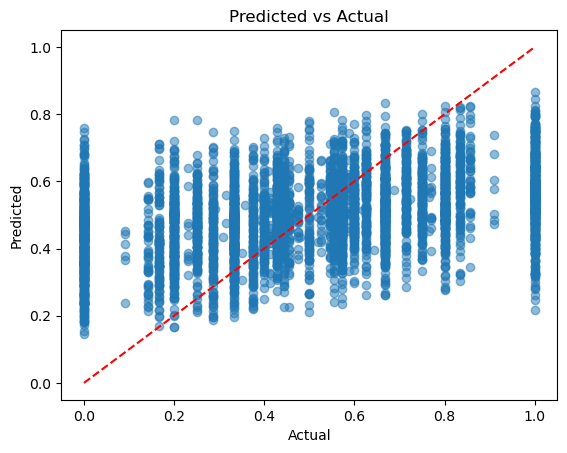

In [7]:
plt.scatter(y_true, y_pred, alpha=0.5)
plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Predicted vs Actual')
plt.show()


Elo win predictions typically range from around 0.18 to 0.8. However, in reality, there are matches where a player completely dominates and wins all the frames. Since Elo ratings always assign each player a nonzero chance of winning and all players have non-zero rating points, the predicted probabilities are never exactly 0 or 1. While this approach is generally suitable for sports predictions, it doesn't account for extreme outcomes, leading to some large prediction errors.

In [8]:
residuals = y_true-y_pred

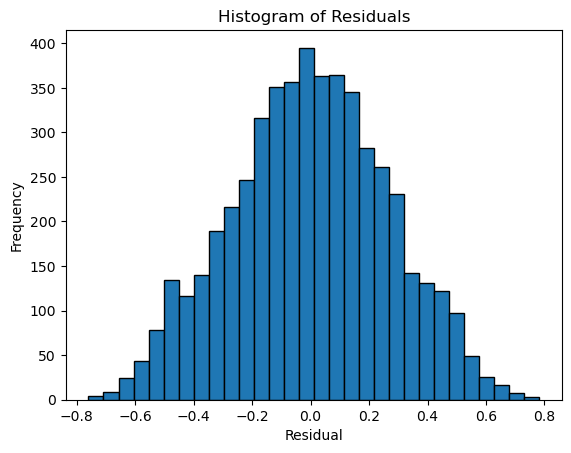

In [9]:
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()


#### Holdout set and time series split for cross validation

We divide our data into six chronologically ordered windows, reserving the last chunk as a holdout set for final model evaluation. For cross-validation during model training and hyperparameter tuning, we use the first five chunks with time series splitting. To compare model performance during development, we employ a metric based on mean squared error and training size, weighted average root mean squared error (WRMSE), across all folds. Since the training data sizes vary across the time series split folds, using a weighted average—weighted by the training sizes—provides a fairer comparison.

As a first step, we apply these performance measures to evaluate the Elo-based predictions.

In [10]:
n = round(len(df) / 6)
df_holdout = df.tail(n)
df=df.iloc[:-n]


In [11]:
y_elo = df['elo_frame_win_rate']
y = df['win_percentage']

In [12]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

rmse_list = []
train_sizes = []

for train_index, test_index in tscv.split(y):
    print(f"  Train size: {len(train_index)}")
    print(f"  Test size:  {len(test_index)}")
    y_test = y.iloc[test_index]
    y_pred = y_elo.iloc[test_index]

    rmse = root_mean_squared_error(y_test, y_pred)
    rmse_list.append(rmse)
    train_sizes.append(len(train_index))

    print(f"Fold RMSE: {rmse} \n")


  Train size: 705
  Test size:  702
Fold RMSE: 0.30842799898297985 

  Train size: 1407
  Test size:  702
Fold RMSE: 0.25361171558668116 

  Train size: 2109
  Test size:  702
Fold RMSE: 0.26101867851099153 

  Train size: 2811
  Test size:  702
Fold RMSE: 0.2391207613078991 

  Train size: 3513
  Test size:  702
Fold RMSE: 0.30301371411286526 



In [13]:
weighted_rmse = np.average(rmse_list, weights=train_sizes)
print(f"Weighted Avg RMSE:   {weighted_rmse:.4f}")

Weighted Avg RMSE:   0.2714


##### RMSE on final validation set
This step will be done for the other models only at the very end once we have done hyperparameter tuning with the rest of the data.

In [14]:
y_test = df_holdout["win_percentage"]
y_pred = df_holdout["elo_frame_win_rate"]

rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE for final validation on holdout set:   {rmse:.4f}")

RMSE for final validation on holdout set:   0.2666
